# BasketIQ — Step 4: Customer Segmentation with K-Means Clustering

**Goal of this notebook:** instead of the manual rule-based segments from Step 3 (`Champions`, `At Risk`, etc.), let a clustering algorithm (**K-Means**) discover customer groups directly from the data.

Why do this in addition to the RFM rules?
- The rule-based segments in Step 3 use thresholds we chose by hand (e.g. "R score >= 4").
- K-Means finds groups based on the *actual structure* of the data, which can reveal patterns we didn't think to hard-code, and gives us a more data-driven segmentation to compare against.

## 1. Import libraries and load the RFM table

We reuse the `rfm_table.csv` file saved in the previous notebook, so we don't need to recompute Recency/Frequency/Monetary from scratch.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [11]:
RFM_PATH = Path('..') / 'data' / 'processed' / 'rfm_table.csv'

rfm = pd.read_csv(RFM_PATH)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Needs Attention
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customers
4,12350,310,1,334.40,1,1,2,112,Lost


## 2. Check for skewness before clustering

Retail data like `Monetary` and `Frequency` is almost always **right-skewed**: most customers spend a modest amount, but a handful of big spenders sit far out on the right side of the distribution. K-Means is sensitive to this — those few extreme customers can pull cluster centers toward themselves and create tiny, meaningless clusters that only contain outliers, while everyone else gets lumped into one giant, mixed cluster.

We check this visually before deciding whether to fix it.

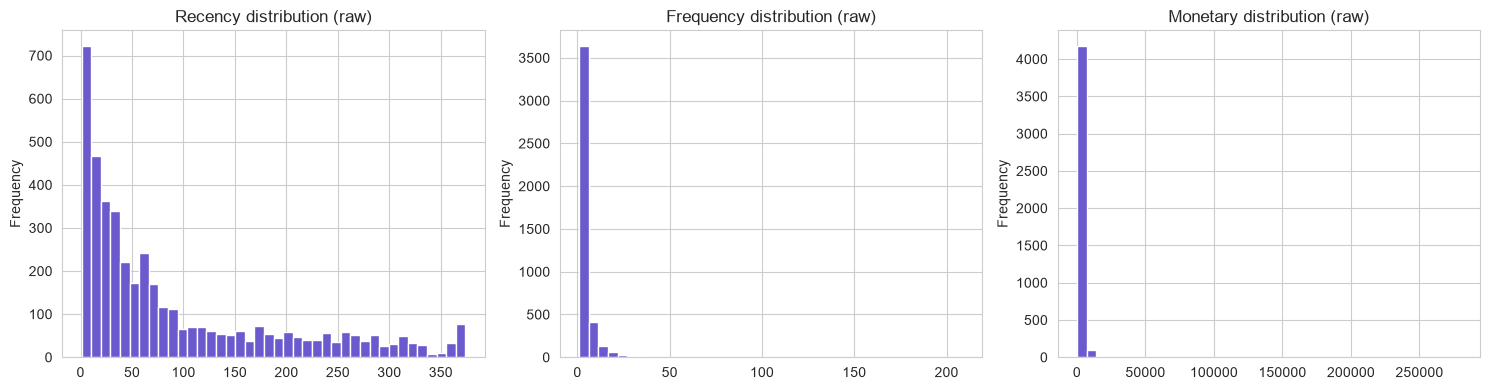

Skewness (0 = symmetric, higher = more skewed to the right):
Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    rfm[col].plot(kind='hist', bins=40, ax=ax, color='slateblue')
    ax.set_title(f'{col} distribution (raw)')
plt.tight_layout()
plt.show()

print('Skewness (0 = symmetric, higher = more skewed to the right):')
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())

## 3. Fix skewness with a log transform

`Frequency` and `Monetary` are usually heavily skewed (skewness well above 1), while `Recency` is naturally more evenly spread since it's bounded by the dataset's date range. To fix the skewed columns, we apply `log1p` (which computes `log(1 + x)` — the `+1` safely handles any zero values, since `log(0)` is undefined).

This compresses the extreme high values so they don't dominate the distance calculations that K-Means relies on, without discarding any customers or data.

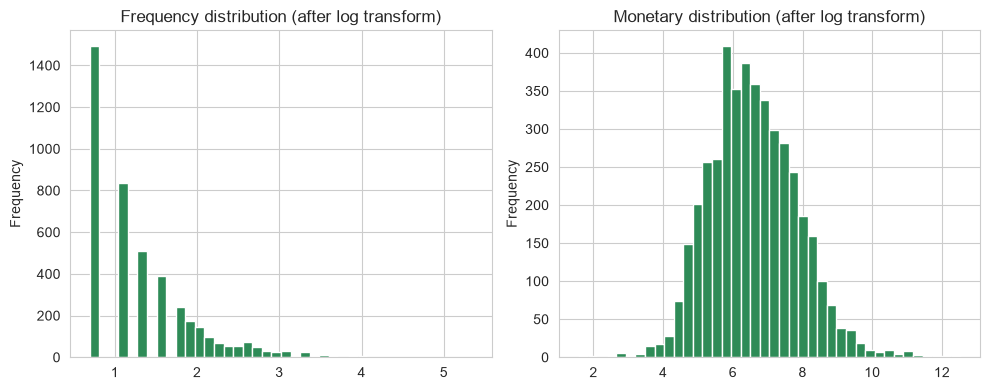

Skewness after log transform:
Frequency_log    1.208652
Monetary_log     0.396599
dtype: float64


In [13]:
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rfm['Frequency_log'].plot(kind='hist', bins=40, ax=axes[0], color='seagreen')
axes[0].set_title('Frequency distribution (after log transform)')
rfm['Monetary_log'].plot(kind='hist', bins=40, ax=axes[1], color='seagreen')
axes[1].set_title('Monetary distribution (after log transform)')
plt.tight_layout()
plt.show()

print('Skewness after log transform:')
print(rfm[['Frequency_log', 'Monetary_log']].skew())

## 4. Scale the data

K-Means groups points based on **distance**, so all features need to be on the same scale. We use `Recency` (raw) together with the two new log-transformed columns, and scale all three to mean = 0, standard deviation = 1 with `StandardScaler` so each one contributes fairly to the clustering.

In [14]:
features = rfm[['Recency', 'Frequency_log', 'Monetary_log']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Quick sanity check: mean should be ~0 and std should be ~1 for every column now
pd.DataFrame(features_scaled, columns=['Recency', 'Frequency_log', 'Monetary_log']).describe().loc[['mean', 'std']]

,Recency,Frequency_log,Monetary_log
mean,2.702618e-17,-8.189750e-18,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00


## 5. Find the right number of clusters (the Elbow Method)

K-Means needs to be told in advance how many clusters (`k`) to create — it doesn't decide this on its own; the algorithm's math requires a fixed number of centers to initialize. To pick a good value, we run K-Means multiple times with different values of `k` and track the **inertia** (how tightly grouped the points are within each cluster — lower is better).

Inertia always goes down as `k` increases. We're looking for the "elbow" — the point where adding more clusters stops giving a meaningful improvement. This is a heuristic we apply by eye; K-Means itself has no way to choose `k` for us.

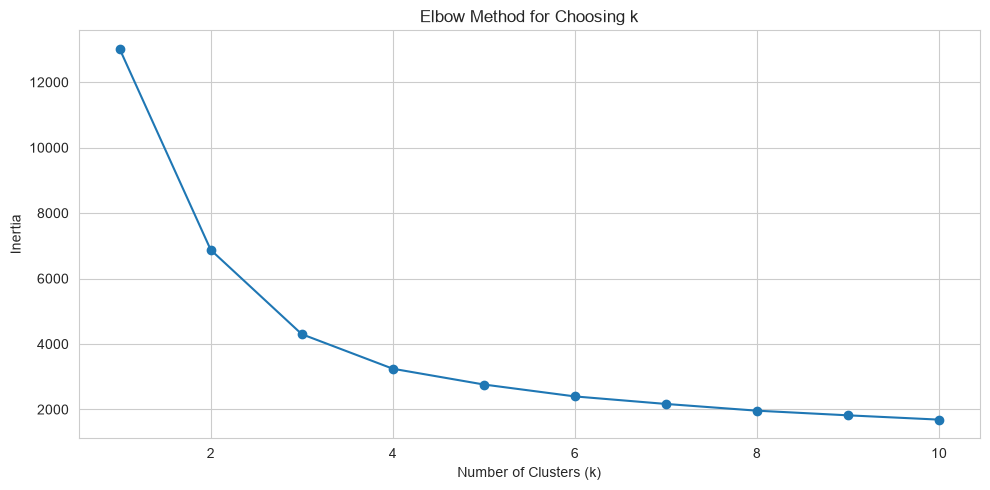

In [15]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    # random_state=42 makes the result reproducible (same clusters every time we re-run this cell)
    # n_init=10 runs K-Means 10 times with different starting points and keeps the best result
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia_values.append(kmeans.inertia_)

fig, ax = plt.subplots()
ax.plot(list(k_range), inertia_values, marker='o')
ax.set_title('Elbow Method for Choosing k')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()

## 6. Fit the final K-Means model

Look at the elbow chart above and pick the `k` where the curve visibly bends and flattens out. Change `chosen_k` below if a different value looks like the elbow on your chart.

In [16]:
chosen_k = 4  # <-- adjust this based on where YOUR elbow chart bends

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(features_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,Frequency_log,Monetary_log,Cluster
0,12346,326,1,77183.60,1,1,5,115,Needs Attention,0.693147,11.253955,3
1,12347,2,7,4310.00,5,5,5,555,Champions,2.079442,8.368925,2
2,12348,75,4,1797.24,2,4,4,244,At Risk,1.609438,7.494564,3
3,12349,19,1,1757.55,4,1,4,414,New Customers,0.693147,7.472245,3
4,12350,310,1,334.40,1,1,2,112,Lost,0.693147,5.815324,1


## 7. Profile each cluster

A cluster label like `0`, `1`, `2`, `3` means nothing on its own. We compute the average Recency, Frequency, and Monetary (raw, unscaled values — easier to read than the log-transformed ones) of each cluster to understand what kind of customer it represents, and check that cluster sizes are reasonably balanced (no more tiny 10-person clusters caused by outliers).

In [17]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['CustomerCount'] = rfm['Cluster'].value_counts()

cluster_profile

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,58.0,1.5,384.2,1377
1,259.4,1.4,385.4,938
2,19.8,15.8,9823.4,571
3,46.1,4.2,1644.3,1452


## 8. Visualize the clusters

We plot Frequency vs. Monetary (colored by cluster) to see the groups visually. We use the log-transformed versions for the plot too, since that's the space the algorithm actually clustered in — the raw version would still look squashed by outliers.

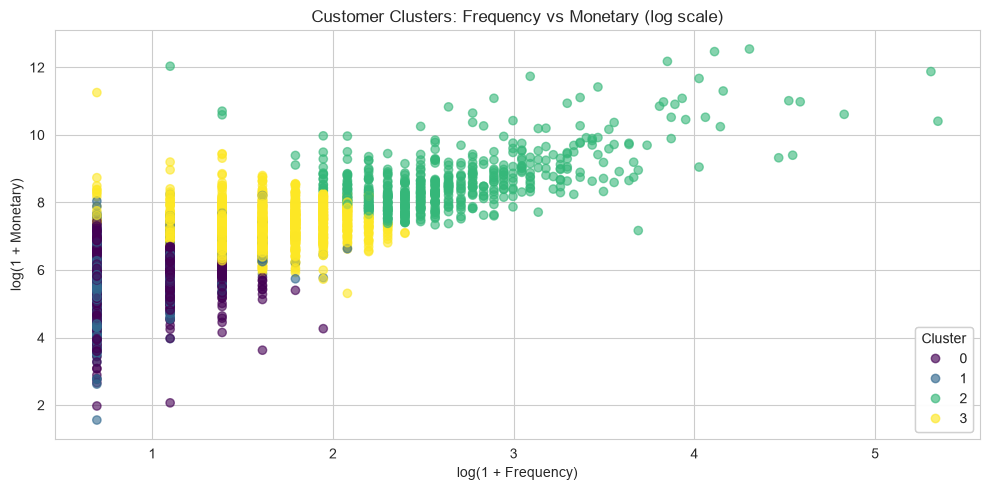

In [18]:
fig, ax = plt.subplots()
scatter = ax.scatter(rfm['Frequency_log'], rfm['Monetary_log'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
ax.set_title('Customer Clusters: Frequency vs Monetary (log scale)')
ax.set_xlabel('log(1 + Frequency)')
ax.set_ylabel('log(1 + Monetary)')
legend1 = ax.legend(*scatter.legend_elements(), title='Cluster')
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

## 9. Compare clusters to the manual RFM segments

This cross-tab shows how the automatic K-Means clusters line up with the manual segments from Step 3. If they mostly agree, it confirms our manual rules were reasonable. If they diverge a lot, the clustering may be picking up patterns the manual rules missed.

In [19]:
pd.crosstab(rfm['Cluster'], rfm['Segment'])

Segment,At Risk,Champions,Lost,Loyal Customers,Needs Attention,New Customers
Cluster,,,,,,
0,19,0,206,204,656,292
1,43,0,615,0,280,0
2,21,491,0,1,58,0
3,192,466,0,291,476,27


## 10. Save the final customer table

We drop the two temporary log-transformed helper columns before saving, since they were only needed for clustering and would be confusing in a table meant for downstream analysis or reporting.

In [20]:
OUTPUT_PATH = Path('..') / 'data' / 'processed' / 'rfm_with_clusters.csv'

rfm_to_save = rfm.drop(columns=['Frequency_log', 'Monetary_log'])
rfm_to_save.to_csv(OUTPUT_PATH, index=False)
print(f'Saved final customer table to: {OUTPUT_PATH.resolve()}')

Saved final customer table to: D:\New folder\BasketIQ\data\processed\rfm_with_clusters.csv
